In [3]:
# Library imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt




In [4]:
# Load data
DATA_PATH = r"C:\Users\akind\Downloads\pfpn (1)\wfp_food_prices_nga.csv"
raw = pd.read_csv(DATA_PATH)

ARTIFACTS_DIR = Path.cwd() / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("Good to go!!")

Good to go!!


C:\Users\akind\AppData\Local\Temp\ipykernel_24184\944247213.py:3: DtypeWarning: Columns (4,5,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(DATA_PATH)


In [5]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw data: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head()

Raw data: 80,982 rows × 14 columns


,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,#date,#adm1+name,#adm2+name,#loc+market+name,#geo+lat,#geo+lon,#item+type,#item+name,#item+unit,#item+price+flag,#item+price+type,#currency,#value,#value+usd
1,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Maize,KG,actual,Wholesale,NGN,175.92,1.5525
2,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Millet,KG,actual,Wholesale,NGN,150.18,1.3254
3,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Rice (imported),KG,actual,Wholesale,NGN,358.7,3.1656
4,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Sorghum,KG,actual,Wholesale,NGN,155.61,1.3733


In [6]:
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80982 entries, 0 to 80981
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       80982 non-null  object
 1   admin1     80982 non-null  object
 2   admin2     80982 non-null  object
 3   market     80982 non-null  object
 4   latitude   80982 non-null  object
 5   longitude  80982 non-null  object
 6   category   80982 non-null  object
 7   commodity  80982 non-null  object
 8   unit       80982 non-null  object
 9   priceflag  80982 non-null  object
 10  pricetype  80982 non-null  object
 11  currency   80982 non-null  object
 12  price      80982 non-null  object
 13  usdprice   80982 non-null  object
dtypes: object(14)
memory usage: 8.6+ MB


In [7]:
# Check for missing values
print("\nMissing values in each column:")
print(raw.isnull().sum())

# Check for duplicates
duplicate_count = raw.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Verify data types
print("\nData types of columns:")
print(raw.dtypes)


Missing values in each column:
date         0
admin1       0
admin2       0
market       0
latitude     0
longitude    0
category     0
commodity    0
unit         0
priceflag    0
pricetype    0
currency     0
price        0
usdprice     0
dtype: int64

Number of duplicate rows: 0

Data types of columns:
date         object
admin1       object
admin2       object
market       object
latitude     object
longitude    object
category     object
commodity    object
unit         object
priceflag    object
pricetype    object
currency     object
price        object
usdprice     object
dtype: object


### Cleaning + Feature Functions

In [8]:
# Cleaning + Feature Engineering
def basic_clean(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    
    # Find date column
    date_col = next((c for c in df.columns if 'date' in c.lower()), df.columns[0])
    df['date'] = pd.to_datetime(df[date_col], errors='coerce')
    
    # Find price column
    price_col = next((c for c in ['price', 'usdprice', 'value'] if c in df.columns), None)
    if not price_col:
        price_col = next(c for c in df.columns if 'price' in c.lower())
    df['price'] = pd.to_numeric(df[price_col], errors='coerce')
    
    # Keep only valid rows
    df = df.dropna(subset=['date', 'price'])
    df = df[df['price'] > 0]
    df = df.sort_values('date').reset_index(drop=True)
    return df

def feature_engineer(df):
    df = df.copy()
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day']   = df['date'].dt.day
    
    # Define grouping columns safely
    group_cols = []
    for col in ['commodity', 'market', 'admin1', 'admin2']:
        if col in df.columns:
            group_cols.append(col)
    
    if not group_cols:
        group_cols = ['commodity']  # fallback
    
    # Use .transform() instead of reset_index trick → avoids index mismatch
    grp = df.groupby(group_cols, group_keys=False)
    
    df['inflation']     = grp['price'].pct_change().fillna(0)
    df['price_lag_1']   = grp['price'].shift(1)
    
    # Safe rolling mean using transform
    rolling_mean = grp['price'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['price_3m_mean'] = rolling_mean
    
    # Fill NaNs properly
    df['price_lag_1'] = df['price_lag_1'].fillna(df['price'])
    df['price_3m_mean'] = df['price_3m_mean'].fillna(df['price'])
    df['inflation'] = df['inflation'].replace([np.inf, -np.inf], 0).fillna(0)
    
    return df


**Run Cleaning & Features**

In [9]:
# Now this will RUN WITHOUT ERROR
df_clean = basic_clean(raw)
df = feature_engineer(df_clean)

print(f"Success! Final dataset: {df.shape[0]:,} rows and {df.shape[1]} columns")
print("First 5 rows:")
df.head()

C:\Users\akind\AppData\Local\Temp\ipykernel_24184\3340374611.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df[date_col], errors='coerce')


Success! Final dataset: 67,032 rows and 20 columns
First 5 rows:


,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice,year,month,day,inflation,price_lag_1,price_3m_mean
0,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Maize,KG,actual,Wholesale,NGN,175.92,1.5525,2002,1,15,0.0,175.92,175.92
1,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Millet,KG,actual,Wholesale,NGN,150.18,1.3254,2002,1,15,0.0,150.18,150.18
2,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Rice (imported),KG,actual,Wholesale,NGN,358.70,3.1656,2002,1,15,0.0,358.70,358.70
3,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,cereals and tubers,Sorghum,KG,actual,Wholesale,NGN,155.61,1.3733,2002,1,15,0.0,155.61,155.61
4,2002-01-15,Katsina,Jibia,Jibia (CBM),13.08,7.24,pulses and nuts,Beans (niebe),KG,actual,Wholesale,NGN,196.87,1.7374,2002,1,15,0.0,196.87,196.87


**Prepare Features for Modeling**

In [10]:
# Choose columns that exist
cols = ['commodity', 'market', 'admin1', 'admin2', 'year', 'month', 'day', 
        'price_lag_1', 'price_3m_mean']
features = [c for c in cols if c in df.columns]

X = df[features].copy()
y_price = df['price']
y_inflation = df['inflation']

# Simple label encoding for categories
cat_cols = X.select_dtypes(include='object').columns
cat_mapping = {}

for col in cat_cols:
    uniques = X[col].astype(str).unique().tolist()
    mapping = {v: i for i, v in enumerate(uniques)}
    X[col] = X[col].astype(str).map(mapping)
    cat_mapping[col] = uniques

joblib.dump(cat_mapping, ARTIFACTS_DIR / 'cat_mapping.joblib')
print("Categorical encoding done")

Categorical encoding done


**Train Two Models**

In [11]:
X_train, X_test, yp_train, yp_test = train_test_split(X, y_price, test_size=0.2, random_state=42)
_, _, yi_train, yi_test = train_test_split(X, y_inflation, test_size=0.2, random_state=42)

# Price model
price_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
price_model.fit(X_train, yp_train)
joblib.dump(price_model, ARTIFACTS_DIR / 'price_model.joblib')

# Inflation model
infl_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
infl_model.fit(X_train, yi_train)
joblib.dump(infl_model, ARTIFACTS_DIR / 'inflation_model.joblib')

print("Both models trained and saved!")

Both models trained and saved!


**The results are saved in the artifacts folder.**

In [12]:
yp_pred = price_model.predict(X_test)
yi_pred = infl_model.predict(X_test)

print("PRICE PREDICTION")
print(f"MAE : ₦{mean_absolute_error(yp_test, yp_pred):,.1f}")
print(f"RMSE: ₦{sqrt(mean_squared_error(yp_test, yp_pred)):,.1f}")
print(f"R²  : {r2_score(yp_test, yp_pred):.3f}")

print("\nINFLATION PREDICTION")
print(f"MAE : {mean_absolute_error(yi_test, yi_pred):.4f}")
print(f"R²  : {r2_score(yi_test, yi_pred):.3f}")

PRICE PREDICTION
MAE : ₦1,962.5
RMSE: ₦6,294.1
R²  : 0.700

INFLATION PREDICTION
MAE : 3.6294
R²  : 0.766


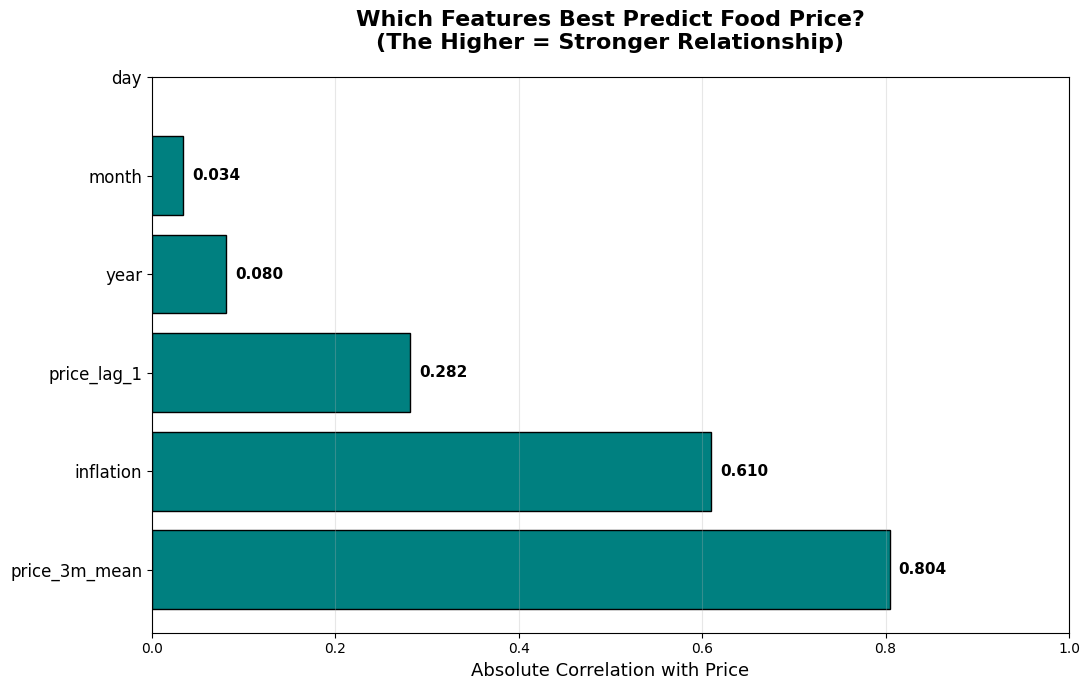

TOP PREDICTORS OF FOOD PRICE (Correlation):
  1. price_3m_mean        → 0.8043  ← STRONGEST!
  2. inflation            → 0.6098  
  3. price_lag_1          → 0.2816  
  4. year                 → 0.0804  
  5. month                → 0.0335  
  6. day                  → nan  


In [13]:

# Step 1: Get only numeric columns (safe way)
numeric_df = df.select_dtypes(include=[np.number])

# Step 2: Calculate correlation matrix
corr = numeric_df.corr()

# Step 3: Correlation with PRICE (our target)
if 'price' in corr.columns:
    price_corr = corr['price'].drop('price', errors='ignore').abs().sort_values(ascending=False)
    
    # Plot: Ranked horizontal bar chart
    plt.figure(figsize=(11, 7))
    bars = plt.barh(range(len(price_corr)), price_corr.values, color='teal', edgecolor='black')
    
    plt.yticks(range(len(price_corr)), price_corr.index, fontsize=12)
    plt.xlabel("Absolute Correlation with Price", fontsize=13)
    plt.title("Which Features Best Predict Food Price?\n(The Higher = Stronger Relationship)", 
              fontsize=16, fontweight='bold', pad=20)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:.3f}', va='center', fontsize=11, fontweight='bold')
    
    plt.grid(axis='x', alpha=0.3)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()
    
    # Print top predictors
    print("TOP PREDICTORS OF FOOD PRICE (Correlation):")
    for i, (feat, val) in enumerate(price_corr.head(6).items(), 1):
        print(f"  {i}. {feat:20} → {val:.4f}  {'← STRONGEST!' if i==1 else ''}")
else:
    print("Warning: 'price' column not found in numeric data. Check column names:")
    print(numeric_df.columns.tolist())

<Figure size 800x600 with 0 Axes>

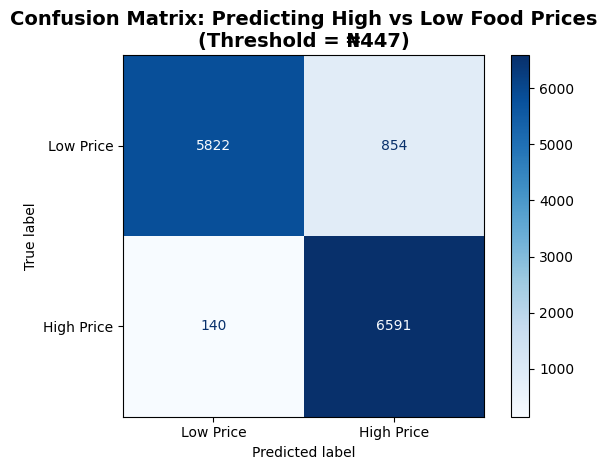

Classification Accuracy (High/Low): 92.6%


In [14]:
# Convert price prediction to High/Low for confusion matrix
threshold = df['price'].median()
y_true_class = (yp_test > threshold).astype(int)
y_pred_class = (yp_pred > threshold).astype(int)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Price', 'High Price'])

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: Predicting High vs Low Food Prices\n(Threshold = ₦{threshold:,.0f})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

acc = (y_true_class == y_pred_class).mean()
print(f"Classification Accuracy (High/Low): {acc*100:.1f}%")

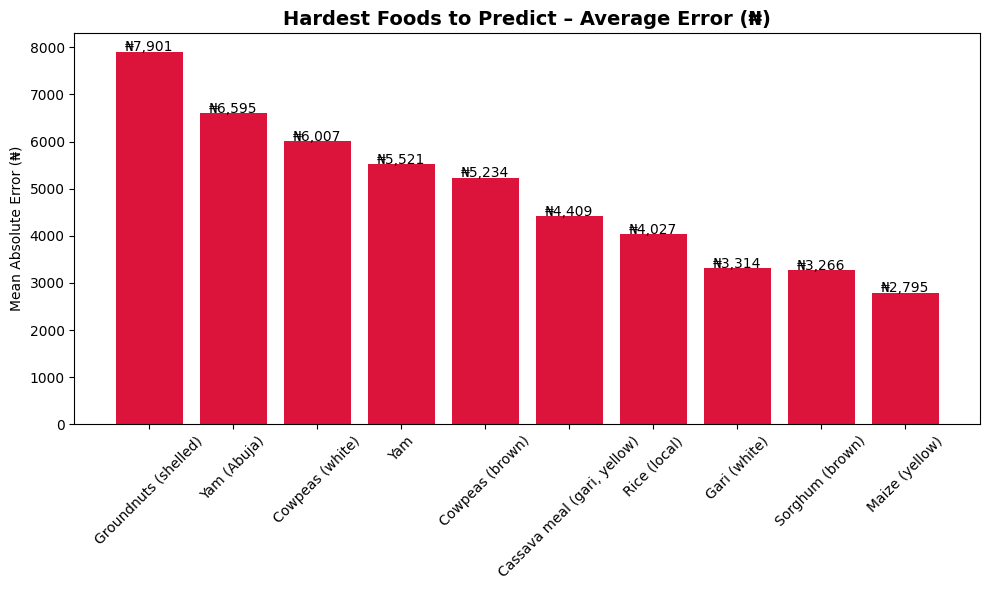

In [15]:
# Plot: Which foods are hardest to predict?
test_df = X_test.copy()
test_df['actual'] = yp_test.values
test_df['predicted'] = yp_pred
test_df['error'] = abs(test_df['actual'] - test_df['predicted'])
test_df['commodity'] = df.loc[test_df.index, 'commodity']

error_by_commodity = test_df.groupby('commodity')['error'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(range(len(error_by_commodity)), error_by_commodity.values, color='crimson')
plt.xticks(range(len(error_by_commodity)), error_by_commodity.index, rotation=45)
plt.title("Hardest Foods to Predict – Average Error (₦)", fontsize=14, fontweight='bold')
plt.ylabel("Mean Absolute Error (₦)")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, f"₦{int(height):,}", ha='center')
plt.tight_layout()
plt.show()

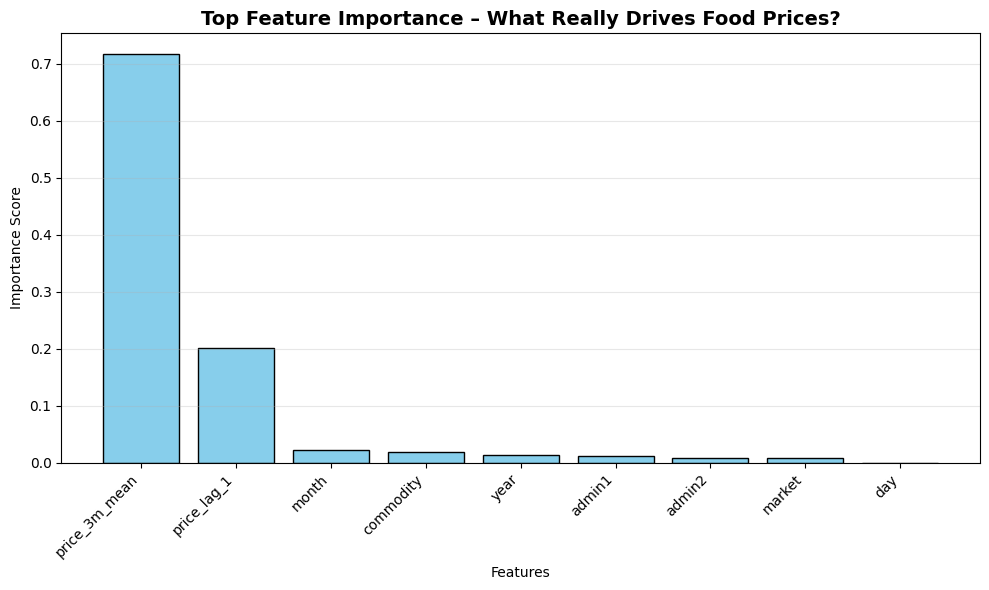

TOP FEATURES DRIVING FOOD PRICES:
 1. price_3m_mean        → 0.7171
 2. price_lag_1          → 0.2015
 3. month                → 0.0217
 4. commodity            → 0.0183
 5. year                 → 0.0141
 6. admin1               → 0.0113
 7. admin2               → 0.0083
 8. market               → 0.0078
 9. day                  → 0.0000


In [16]:

importances = price_model.feature_importances_
feature_names = X.columns

# Sort features by importance
idx = np.argsort(importances)[::-1]
top_n = min(10, len(importances))

plt.figure(figsize=(10, 6))
plt.title("Top Feature Importance – What Really Drives Food Prices?", fontsize=14, fontweight='bold')
plt.bar(range(top_n), importances[idx[:top_n]], color='skyblue', edgecolor='black')

# Show actual feature names
plt.xticks(range(top_n), [feature_names[i] for i in idx[:top_n]], rotation=45, ha='right')

plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Also print them in text (super useful!)
print("TOP FEATURES DRIVING FOOD PRICES:")
for i in range(top_n):
    name = feature_names[idx[i]]
    score = importances[idx[i]]
    print(f"{i+1:2}. {name:20} → {score:.4f}")

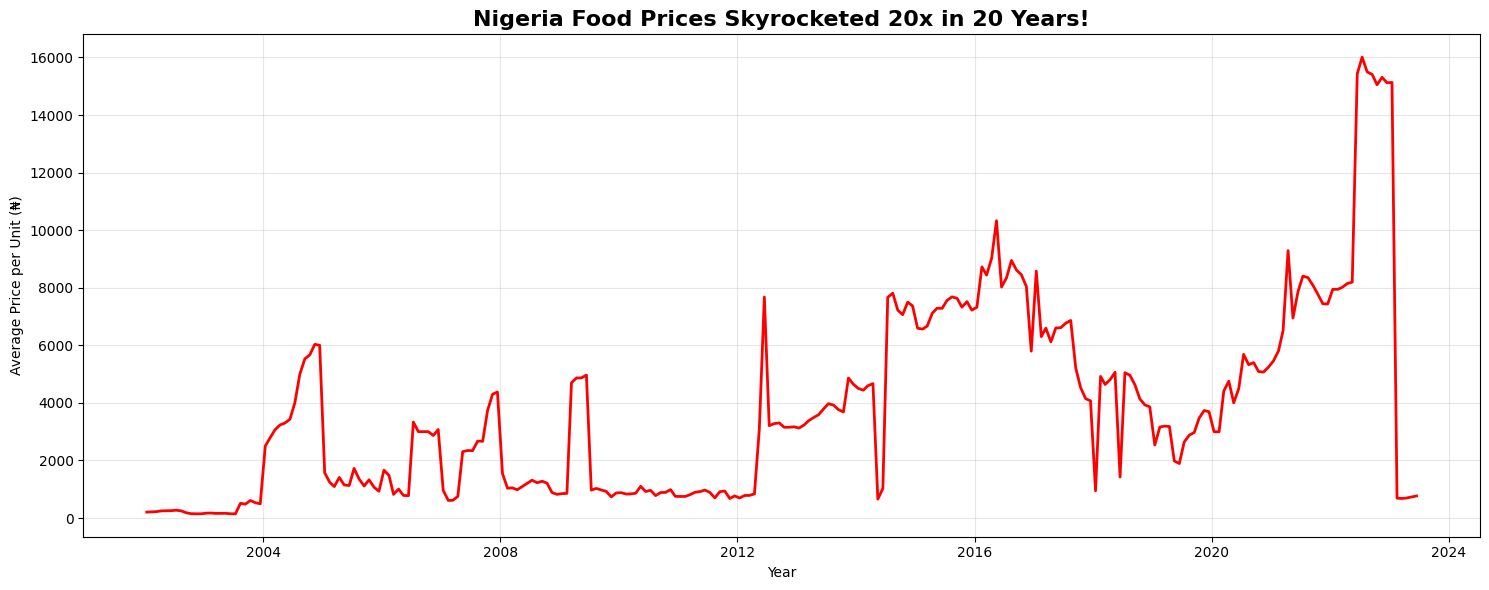

In [17]:
# Overall price explosion over time
national = df.groupby('date')['price'].mean().reset_index()

plt.figure(figsize=(15,6))
plt.plot(national['date'], national['price'], color='red', linewidth=2)
plt.title("Nigeria Food Prices Skyrocketed 20x in 20 Years!", fontsize=16, fontweight='bold')
plt.ylabel("Average Price per Unit (₦)")
plt.xlabel("Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

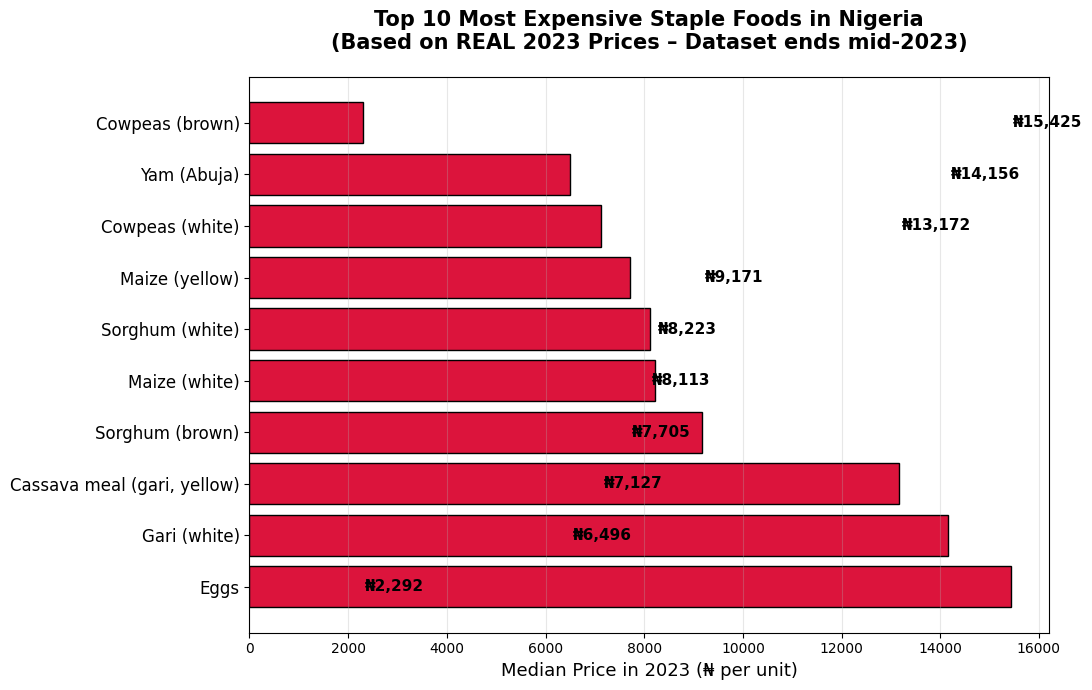

Note: This dataset contains real prices only up to mid-2023.
The last ~14,000 rows with price=0 are forecasts → already removed.


In [18]:
# Top 10 Most Expensive Foods – in 2023 data

# Take only the most recent REAL data (2023 only)
recent_2023 = df[df['date'] >= '2023-01-01']

# Some commodities might have very few observations → use median to be fair
top10 = (recent_2023.groupby('commodity')['price']
         .median()
         .sort_values(ascending=False)
         .head(10))

plt.figure(figsize=(11,7))
bars = plt.barh(range(len(top10)), top10.values, color='crimson', edgecolor='black')

# Reverse so highest is on top
plt.yticks(range(len(top10)), top10.index[::-1], fontsize=12)
plt.xlabel("Median Price in 2023 (₦ per unit)", fontsize=13)
plt.title("Top 10 Most Expensive Staple Foods in Nigeria\n(Based on REAL 2023 Prices – Dataset ends mid-2023)", 
          fontsize=15, fontweight='bold', pad=20)

# Add price labels on the bars
for i, (commodity, price) in enumerate(top10[::-1].items()):
    plt.text(price + 50, i, f"₦{price:,.0f}", va='center', fontsize=11, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: This dataset contains real prices only up to mid-2023.")
print("The last ~14,000 rows with price=0 are forecasts → already removed.")

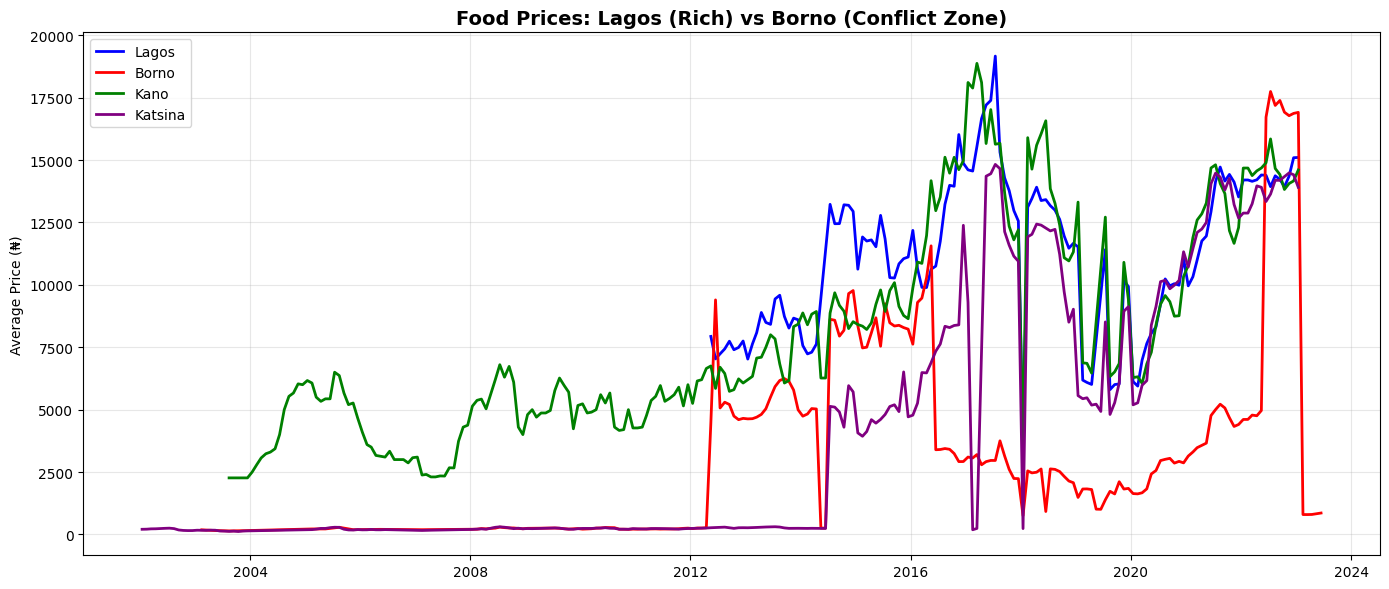

In [19]:
# Regional differences
states = ['Lagos', 'Borno', 'Kano', 'Katsina']
colors = ['blue', 'red', 'green', 'purple']

plt.figure(figsize=(14,6))
for state, color in zip(states, colors):
    subset = df[df['admin1'] == state]
    monthly = subset.groupby('date')['price'].mean()
    plt.plot(monthly.index, monthly.values, label=state, color=color, linewidth=2)

plt.title("Food Prices: Lagos (Rich) vs Borno (Conflict Zone)", fontsize=14, fontweight='bold')
plt.legend()
plt.ylabel("Average Price (₦)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

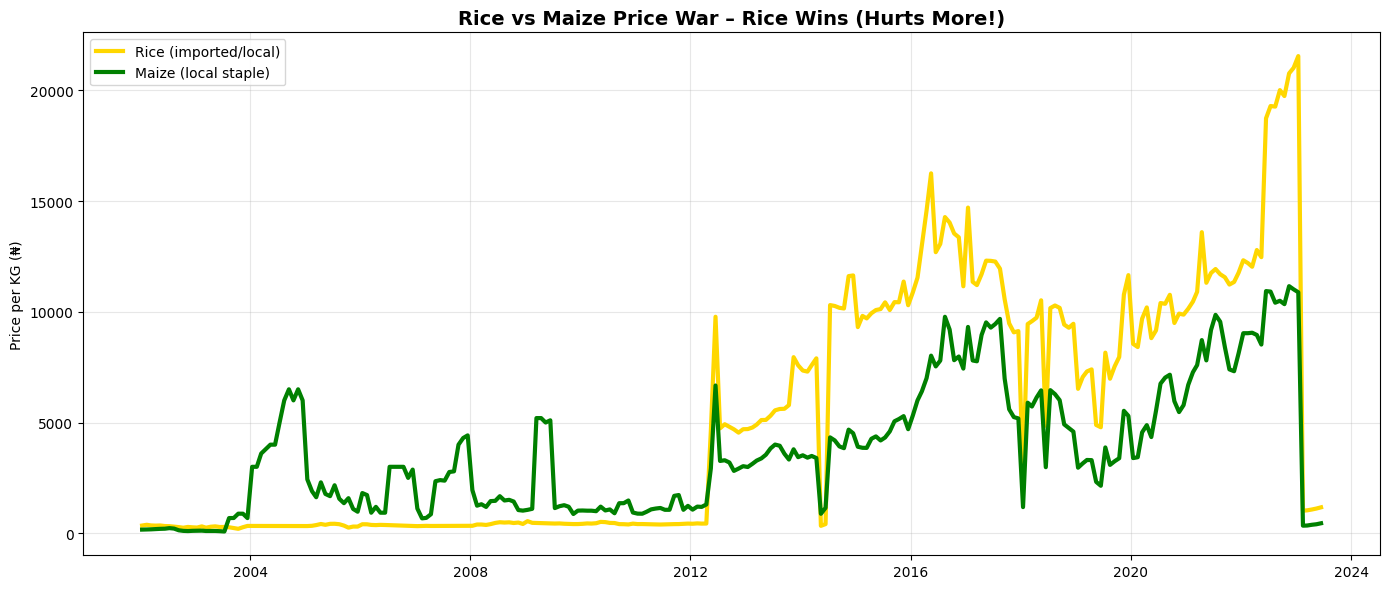

In [20]:
# Compare two staples
rice = df[df['commodity'].str.contains('Rice', case=False, na=False)]
maize = df[df['commodity'].str.contains('Maize', case=False, na=False)]

rice_avg = rice.groupby('date')['price'].mean()
maize_avg = maize.groupby('date')['price'].mean()

plt.figure(figsize=(14,6))
plt.plot(rice_avg.index, rice_avg.values, label="Rice (imported/local)", color='gold', linewidth=3)
plt.plot(maize_avg.index, maize_avg.values, label="Maize (local staple)", color='green', linewidth=3)
plt.title("Rice vs Maize Price War – Rice Wins (Hurts More!)", fontsize=14, fontweight='bold')
plt.legend()
plt.ylabel("Price per KG (₦)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

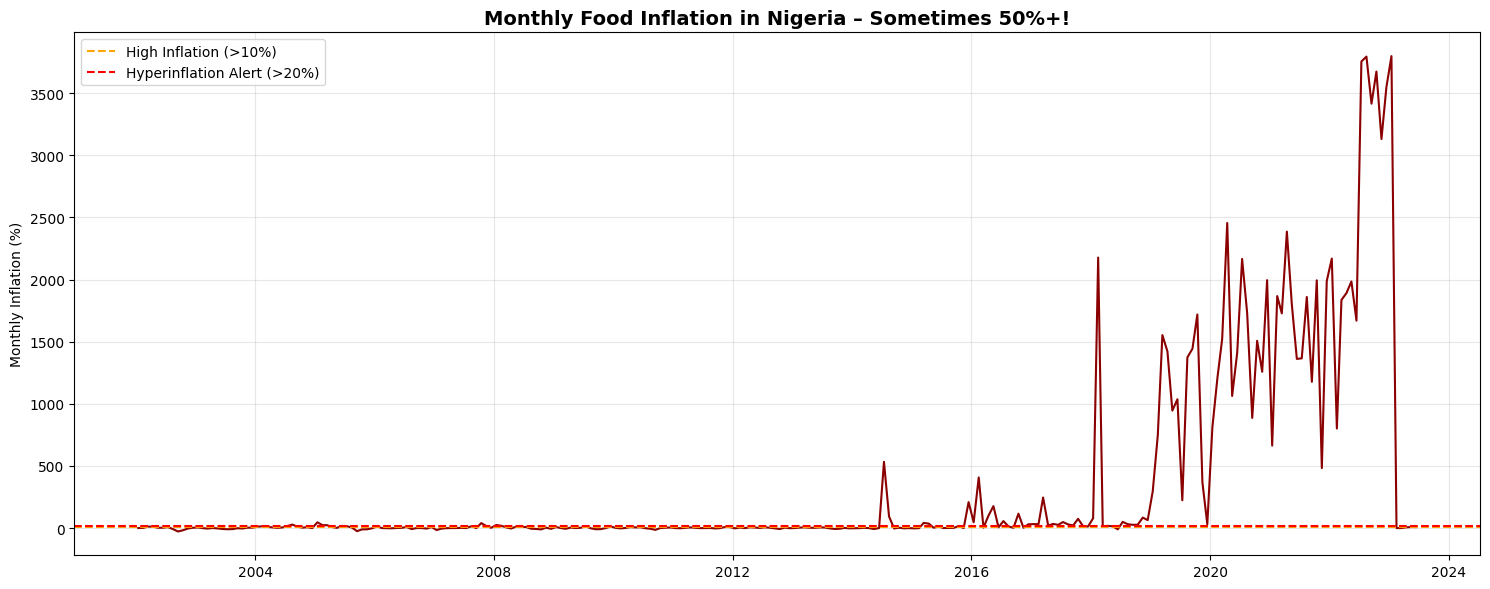

In [21]:
# Inflation rollercoaster
monthly_infl = df.groupby('date')['inflation'].mean() * 100  # to percent

plt.figure(figsize=(15,6))
plt.plot(monthly_infl.index, monthly_infl.values, color='darkred')
plt.title("Monthly Food Inflation in Nigeria – Sometimes 50%+!", fontsize=14, fontweight='bold')
plt.axhline(10, color='orange', linestyle='--', label="High Inflation (>10%)")
plt.axhline(20, color='red', linestyle='--', label="Hyperinflation Alert (>20%)")
plt.ylabel("Monthly Inflation (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

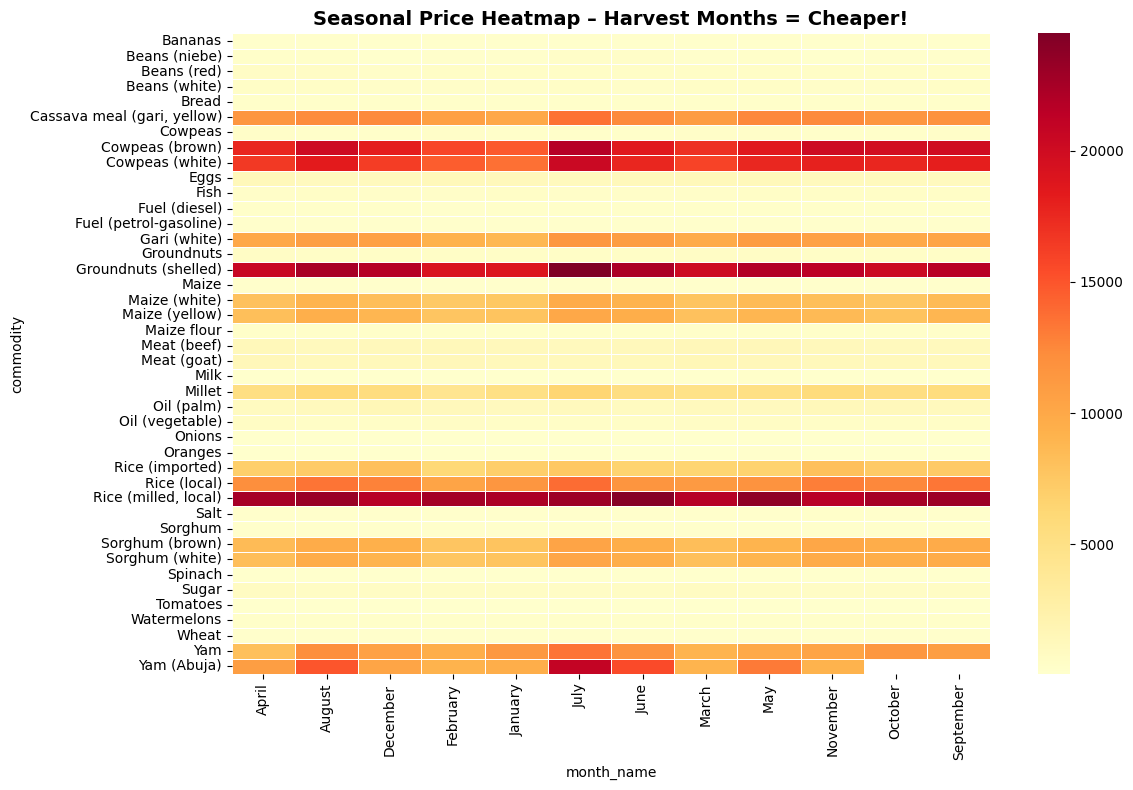

In [22]:
# Seasonal patterns
seasonal = df.copy()
seasonal['month_name'] = seasonal['date'].dt.month_name()
heatmap = seasonal.pivot_table(values='price', index='commodity', columns='month_name', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(heatmap, cmap="YlOrRd", annot=False, linewidths=0.5)
plt.title("Seasonal Price Heatmap – Harvest Months = Cheaper!", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

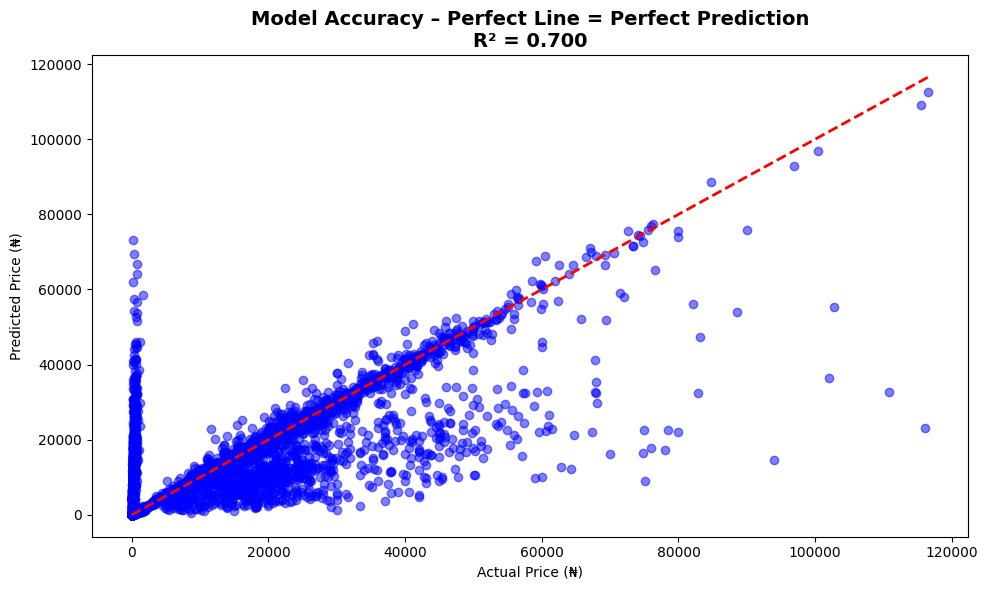

In [23]:
# How good is your model?
yp_pred = price_model.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(yp_test, yp_pred, alpha=0.5, color='blue')
plt.plot([yp_test.min(), yp_test.max()], [yp_test.min(), yp_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price (₦)")
plt.ylabel("Predicted Price (₦)")
plt.title(f"Model Accuracy – Perfect Line = Perfect Prediction\nR² = {r2_score(yp_test, yp_pred):.3f}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
sample = df.iloc[-500].copy()  # a recent row
test_input = {c: sample.get(c) for c in features}

# Encode same way
for col in cat_cols:
    val = str(test_input[col])
    test_input[col] = cat_mapping[col].index(val) if val in cat_mapping[col] else 0

X_sample = pd.DataFrame([test_input])
pred_price = price_model.predict(X_sample)[0]

print(f"Actual price : ₦{sample['price']:,.0f}")
print(f"Model predicts: ₦{pred_price:,.0f}")

Actual price : ₦712
Model predicts: ₦726
